# Setup

## Load packages + settings

In [114]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import xarray as xr
GTE_DIR=os.environ["GTE_DIR"]
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.Helper_fun import float_range
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import cmcrameri.cm
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.gridspec as gridspec

In [2]:
# import sys
# !{sys.executable} -m pip install pycairo

Setup matplotlib


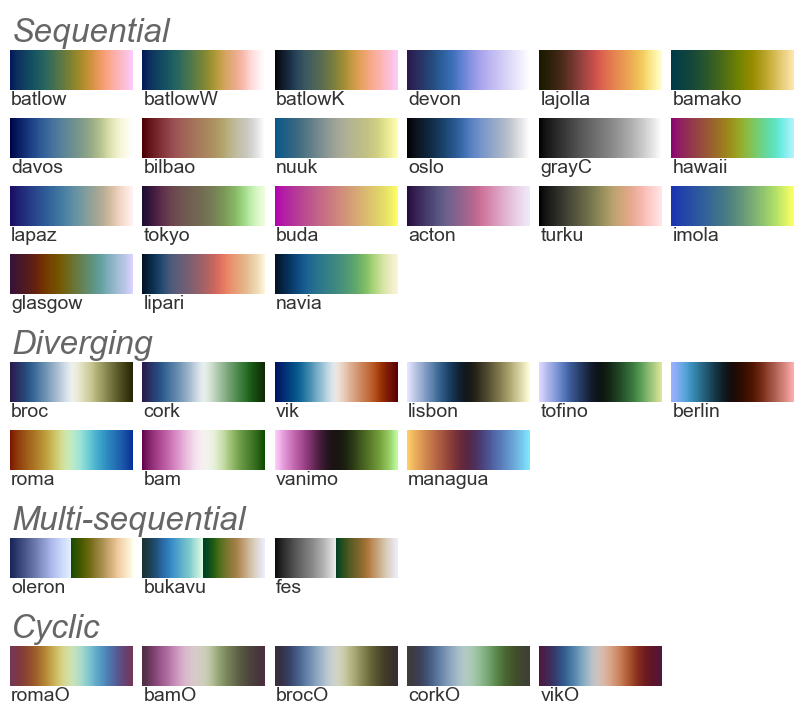

In [3]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":6})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()

Set parameters

In [4]:
config = read_config(
    os.path.join('/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml'))
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2016)]
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# classifiacation_palette = ['#00429d', '#93003a','#ffffe0']
classifiacation_palette = cmcrameri.cm.actonS.colors[[i for i in range(10) if i != 1],:]
temperature_palette = ["#0d0d0f",'#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
default_colormap=cmcrameri.cm.acton


Load data

## Load data

In [5]:
cpp_data_sp = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/sp/2010/01/01/CPPin20100101120000405SVMSG01MD.nc")
ctx_data_sp = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/sp/2010/01/01/CTXin20100101120000405SVMSG01MD.nc")
aggregated_sp  = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Resampled_Data/sp/2010/01/01/Agg_03_20100101120000.nc")
aux_data_sp = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/sp/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)

In [6]:
cpp_data_np = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/2010/01/01/CPPin20100101120000405SVMSG01MD.nc")
ctx_data_np = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/2010/01/01/CTXin20100101120000405SVMSG01MD.nc")
aggregated_np  = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/Resampled_Data/np/2010/01/01/Agg_03_20100101120000.nc")
aux_data_np = xr.load_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)


In [7]:
aux_data_full_globe = xr.load_dataset("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/aux_data_full_globe.nc",decode_times=False)

# Ploting

In [8]:
custom_cmap = ListedColormap(['white', 'red', 'blue'])

# Define a norm that maps the data values to the correct colors.
# The boundaries are set such that values between -0.5 and 0.5 are gray, 
# 0.5 to 1.5 are red, and 1.5 to 2.5 are blue.
norm = BoundaryNorm([ -0.5, 0.5, 1.5, 2.5 ], custom_cmap.N)

In [ ]:
def put_on_globe(arr_np,arr_sp):
    assert arr_np.shape==arr_sp.shape,"Two arrays of unequal size"
    assert len(arr_np.shape)==2,"The input arrays are not 2D"
    
    arr_shape=arr_np.shape
    full_image = np.full((3712,3712),np.nan)
    start_idx_x=int((full_image.shape[1]-arr_shape[1])/2)
    end_idx_x=start_idx_x+arr_shape[1]
    full_image[51:51+arr_shape[0],start_idx_x:end_idx_x]=arr_np
    full_image[3660-arr_shape[0]:3660,start_idx_x:end_idx_x]=arr_sp
    return full_image


In [69]:
def first_and_last_true2d(arr):
    arr_copy = arr.copy()
    m, n = arr.shape

    # mask of positives
    mask = arr > 0

    # --- first positive in each row ---
    # where mask=True take the column index, else n (past-the-end)
    idxs = np.where(mask, np.arange(n), n)
    first_pos = idxs.min(axis=1)        # min gives first True (or n)

    # --- last positive in each row ---
    # where mask=True take the column index, else -1 (before-the-start)
    idxs_back = np.where(mask, np.arange(n), -1)
    last_pos = idxs_back.max(axis=1)    # max gives last True (or -1)

    # which rows actually had any positives?
    has_pos = mask.any(axis=1)

    rows = np.nonzero(has_pos)[0]       # array of row-indices with positives

    # set first & last to -1
    arr_copy[rows, first_pos[has_pos]] = -1
    arr_copy[rows, last_pos[has_pos]]   = -1

    # count rows with no positives
    count = (~mask.any(axis=1)).sum()
    print(count)
    return arr_copy

def plot_minus1_contour(arr,ax, linewidth=1 ):
    """
    Plot the -1 contour of a 2D array (everything else can be NaN)
    as a single gray line.
    
    Parameters
    ----------
    arr : 2D ndarray
        Your array, with -1 marking the contour and everything else NaN.
    figsize : tuple of int, optional
        Figure size in inches.
    linewidth : float, optional
        Width of the contour line.
    """
    # Boolean mask: True where arr == -1
    mask = (arr == -1).astype(int)

    ax.contour(
        mask,
        levels=[0.5],
        colors='gray',
        linewidths=linewidth,
        antialiased=True,
        alpha=0.2
    )
bounday_array = first_and_last_true2d(aux_data_full_globe.lsm.values[0])
def plot_background_map(ax):
    plot_minus1_contour(bounday_array,ax)
    ax.imshow(put_on_globe(aux_data_np.lsm[0].values,aux_data_sp.lsm[0].values),alpha=0.2,cmap="Grays")
    

102


In [54]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'mycmap', 
    ['#ca0020', '#0571b0']
)

cph_cmap = mcolors.LinearSegmentedColormap.from_list(
    'mycmap', 
    [
    cmcrameri.cm.managua.colors[0],
    cmcrameri.cm.managua.colors[-1]]
)
#['#e41a1c', '#377eb8']
# Create a normalization to map 1 -> #ca0020, 2 -> #0571b0
ctt_cmap="plasma"
cph_norm = mcolors.Normalize(vmin=1, vmax=2)
ctt_vmin=200
ctt_vmax=300

In [ ]:
def put_on_globe_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp):
    left_half = np.full((3712,3712),np.nan)
    right_half = np.full((3712,3712),np.nan)
    arr_shape = cph_np.shape
    start_idx_x=int((right_half.shape[1]-arr_shape[1])/2)
    start_idx_y=51
    end_idx_y = 3660
    end_idx_x=start_idx_x+arr_shape[1]
    mid_idx_x=int((start_idx_x+end_idx_x)/2)
    left_half[start_idx_y:start_idx_y+arr_shape[0],start_idx_x:mid_idx_x]=cph_np[:,:mid_idx_x-start_idx_x]
    left_half[end_idx_y-arr_shape[0]:end_idx_y,start_idx_x:mid_idx_x]=cph_sp[:,:mid_idx_x-start_idx_x]
    right_half[start_idx_y:start_idx_y+arr_shape[0],mid_idx_x:end_idx_x]=ctt_np[:,-(end_idx_x-mid_idx_x):]
    right_half[end_idx_y-arr_shape[0]:end_idx_y,mid_idx_x:end_idx_x]=ctt_sp[:,-(end_idx_x-mid_idx_x):]
    return left_half,right_half , (start_idx_x,mid_idx_x,end_idx_x),(start_idx_y,end_idx_y)

def add_ctt_cph_cbars_vertical(im_left,im_right,fig):
    cbar_left = fig.colorbar(im_left, shrink=0.5 ,aspect=10,location='bottom')
    # Set two ticks at 1 and 2, with labels
    cbar_left.set_ticks([1, 2])
    cbar_left.set_ticklabels(['Liquid', 'Ice'],fontsize=6,fontweight='bold')

    tick_labels = cbar_left.ax.yaxis.get_ticklabels()
    # The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
    tick_labels[0].set_verticalalignment('bottom')
    # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_verticalalignment('top')
    cbar_right = fig.colorbar(im_right, shrink=0.5 ,aspect=10,location='top')
    # Force the colorbar range to [1, 2] with no extra margins
    cbar_right.ax.set_ylim(ctt_vmin, ctt_vmax)

    # Set two ticks at 1 and 2, with labels
    cbar_right.set_ticks([ctt_vmin, ctt_vmax])
    cbar_right.set_ticklabels([f'{ctt_vmin:d}K', f'{ctt_vmax:d}K'],fontsize=6,fontweight='bold')
    # Adjust vertical alignment of the two tick labels
    tick_labels = cbar_right.ax.yaxis.get_ticklabels()
    # The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
    tick_labels[0].set_verticalalignment('bottom')
    # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_verticalalignment('top')

def add_axins(left_side,right_side,ax):
    # first inset
    axins_left = ax.inset_axes([0.05, 0.3, 0.4, 0.4], xlim=(1720,1747), ylim=(272,287))
    axins_left.imshow(left_side, cmap=cph_cmap, norm=cph_norm)
    mark_inset(ax, axins_left, loc1=1, loc2=2, fc="none", ec="black", lw=1)
    axins_left.tick_params(
        axis='both',        # both axes
        which='both',       # both major and minor ticks
        left=False,         # no ticks on the left
        right=False,        # no ticks on the right
        bottom=False,       # no ticks on the bottom
        top=False,          # no ticks on the top
        labelleft=False,    # no labels on the left
        labelbottom=False,  # no labels on the bottom
        labelright=False,   # etc.
        labeltop=False
    )
    # second inset
    axins_right = ax.inset_axes([0.55, 0.3, 0.4, 0.4], xlim=(2070,2097), ylim=(3272,3287))
    axins_right.imshow(right_side, cmap=ctt_cmap, vmin = ctt_vmin, vmax=ctt_vmax)
    mark_inset(ax, axins_right, loc1=3, loc2=4, fc="none", ec="black", lw=1,clip_box=None)
    axins_right.tick_params(
        axis='both',        # both axes
        which='both',       # both major and minor ticks
        left=False,         # no ticks on the left
        right=False,        # no ticks on the right
        bottom=False,       # no ticks on the bottom
        top=False,          # no ticks on the top
        labelleft=False,    # no labels on the left
        labelbottom=False,  # no labels on the bottom
        labelright=False,   # etc.
        labeltop=False
    )

def plot_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp,ax):
    cph_np[cph_np<1]=np.nan 
    cph_sp[cph_sp<1]=np.nan
    ctt_np[ctt_np<1]=np.nan 
    ctt_sp[ctt_sp<1]=np.nan
    left_side , right_side, x_tuple,y_tuple = put_on_globe_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp)
    im_left = ax.imshow(left_side, cmap = cph_cmap , norm = cph_norm,interpolation='none')
    im_right =  ax.imshow(right_side,cmap=ctt_cmap, vmax=300, vmin=200,interpolation='none')
    ax.vlines(x_tuple[1],y_tuple[0],y_tuple[1],colors='black',alpha=0.4,linestyles="--",linewidths=1)
    ax.hlines([y_tuple[0]+cph_np.shape[0],y_tuple[1]-cph_np.shape[0]],x_tuple[0],x_tuple[2],colors='black',alpha=0.2,linewidths=1)
    add_axins(left_side,right_side,ax)
    
    return im_left, im_right
  

In [ ]:
def add_ctt_cph_cbars_horizontal(im_left,im_right,fig):
    cbar_left = fig.colorbar(im_left, shrink=0.5 ,aspect=10,location='bottom',anchor=(0.2,1.0))
    # Set two ticks at 1 and 2, with labels
    cbar_left.set_ticks([1, 2])
    cbar_left.set_ticklabels(['Liquid', 'Ice'],fontsize=6)

    tick_labels = cbar_left.ax.xaxis.get_ticklabels()
    # # The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
    tick_labels[0].set_horizontalalignment('left')
    # # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_horizontalalignment('right')
    cbar_right = fig.colorbar(im_right, shrink=0.4 ,aspect=10,location='top',anchor=(0.8,0.0))
    # Force the colorbar range to [1, 2] with no extra margins
    cbar_right.ax.set_xlim(ctt_vmin, ctt_vmax)

    # Set two ticks at 1 and 2, with labels
    cbar_right.set_ticks([ctt_vmin, ctt_vmax])
    cbar_right.set_ticklabels([f'{ctt_vmin:d}K', f'{ctt_vmax:d}K'],fontsize=6)
    # Adjust vertical alignment of the two tick labels
    tick_labels = cbar_right.ax.xaxis.get_ticklabels()
    tick_labels[0].set_horizontalalignment('left')
    # # The second label (index 1) is at value=2 => align its *top* with the colorbar top
    tick_labels[1].set_horizontalalignment('right')

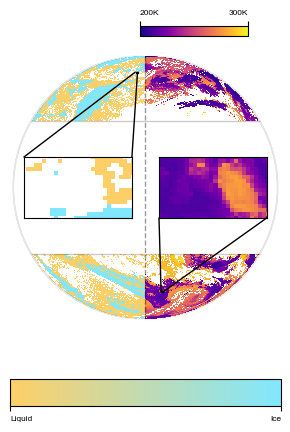

In [ ]:
cph_np= cpp_data_np["cph"].values[0].copy()
cph_sp=cpp_data_sp["cph"].values[0].copy()
ctt_np= ctx_data_np["ctt"].values[0].copy()
ctt_sp=ctx_data_sp["ctt"].values[0].copy()
fig = plt.figure(figsize=(5.501, 11.0236), constrained_layout=True)
gs = gridspec.GridSpec(5, 6,height_ratios=[0.1,1,0.1,1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax1 = fig.add_subplot(gs[1, :3])
ax_colorbar_upper=fig.add_subplot(gs[0, 1])
ax_colorbar_lower=fig.add_subplot(gs[2, 0])
ax1.axis('off')
im_left, im_right =plot_cph_ctt(cph_np,cph_sp,ctt_np,ctt_sp,ax1)
add_ctt_cph_cbars_horizontal(im_left,im_right,fig)
# plot_background_map(ax)
plot_minus1_contour(bounday_array,ax1)
# plt.tight_layout()
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_upper_panel.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

## Old figure

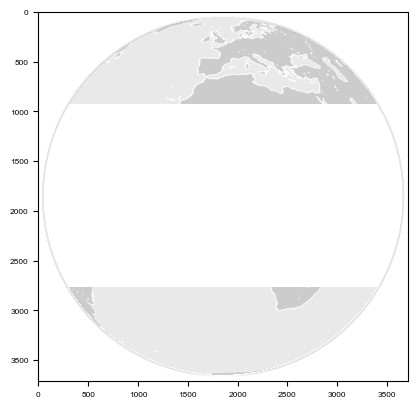

In [14]:
fig, ax = plt.subplots()
ax.imshow(put_on_globe(aux_data_np.lsm[0].values,aux_data_sp.lsm[0].values),alpha=0.2,cmap="Grays")
plot_minus1_contour(bounday_array,ax, linewidth=1 )

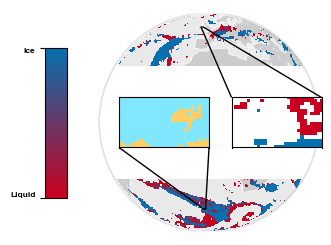

In [ ]:
# Create old figure.
fig = plt.figure(figsize=(3,5))

# Create an axes that fills the entire figure: [left, bottom, width, height]
ax = fig.add_axes([0, 0, 1, 1])
# ax.imshow(aux_data_np.lsm[0,:,:], alpha=0.2,cmap="Greys")
ax.imshow(put_on_globe(aux_data_np.lsm[0].values,aux_data_sp.lsm[0].values),alpha=0.2,cmap="Grays")
plot_minus1_contour(bounday_array,ax, linewidth=1 )
# Display the image.
cph_np= cpp_data_np["cph"].values[0].copy()
cph_sp=cpp_data_sp["cph"].values[0].copy()
cph_np[cph_np<1]=np.nan 
cph_sp[cph_sp<1]=np.nan

im = ax.imshow(put_on_globe(cph_np,cph_sp), cmap = custom_cmap , norm = norm)

# Remove all borders and ticks.
ax.axis('off')
# Create a shorter colorbar
cbar = fig.colorbar(im, shrink=0.3 ,aspect=7,location='left')

# Force the colorbar range to [1, 2] with no extra margins
cbar.ax.set_ylim(1, 2)

# Set two ticks at 1 and 2, with labels
cbar.set_ticks([1, 2])
cbar.set_ticklabels(['Liquid', 'Ice'],fontsize=6,fontweight='bold')

# Adjust vertical alignment of the two tick labels
tick_labels = cbar.ax.yaxis.get_ticklabels()
# The first label (index 0) is at value=1 => align its *bottom* with the colorbar bottom
tick_labels[0].set_verticalalignment('bottom')
# The second label (index 1) is at value=2 => align its *top* with the colorbar top
tick_labels[1].set_verticalalignment('top')

# first inset
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
axins_left = ax.inset_axes([0.6, 0.3, 0.4, 0.4], xlim=(1720,1747), ylim=(272,287))
axins_left.imshow(put_on_globe(cph_np,cph_sp), cmap=custom_cmap, norm=norm)
mark_inset(ax, axins_left, loc1=1, loc2=2, fc="none", ec="black", lw=1)
axins_left.tick_params(
    axis='both',        # both axes
    which='both',       # both major and minor ticks
    left=False,         # no ticks on the left
    right=False,        # no ticks on the right
    bottom=False,       # no ticks on the bottom
    top=False,          # no ticks on the top
    labelleft=False,    # no labels on the left
    labelbottom=False,  # no labels on the bottom
    labelright=False,   # etc.
    labeltop=False
)
# second inset
axins_right = ax.inset_axes([0.1, 0.3, 0.4, 0.4], xlim=(1770,1797), ylim=(3272,3287))
axins_right.imshow(put_on_globe(cph_np,cph_sp), cmap=cph_cmap, norm=norm)
mark_inset(ax, axins_right, loc1=3, loc2=4, fc="none", ec="black", lw=1,clip_box=None)
axins_right.tick_params(
    axis='both',        # both axes
    which='both',       # both major and minor ticks
    left=False,         # no ticks on the left
    right=False,        # no ticks on the right
    bottom=False,       # no ticks on the bottom
    top=False,          # no ticks on the top
    labelleft=False,    # no labels on the left
    labelbottom=False,  # no labels on the bottom
    labelright=False,   # etc.
    labeltop=False
)
